# Heat Wave Analysis: Baseline vs ERA5-Land Model Comparison
## May 25 - June 1, 2019 Extreme Temperature Event

This notebook provides a comprehensive comparison of two UNet models during an intense heat wave event over India.

### **Heat Wave Period:**
- **Dates**: May 25 - June 1, 2019 (8 days)
- **Region**: Northern and Central India
- **Significance**: Severe pre-monsoon heat wave with temperatures exceeding 45°C

### **Models Compared:**

**Model 1: Baseline UNet**
- Training: IMDAA atmospheric variables only (37 variables)
- Data: `indibench_h5_ori`
- Checkpoint: `archive_baseline_unet/checkpoints/last.ckpt`

**Model 2: ERA5-Land Integrated UNet**
- Training: IMDAA + ERA5-Land surface variables (43 variables)
- Additional inputs: soil moisture, heat fluxes, leaf area index
- Data: `indibench_h5`
- Checkpoint: `checkpoints_era5land/india_benchmark/checkpoints/last.ckpt`

### **Analysis Goals:**
1. Characterize the heat wave spatial and temporal extent
2. Compare model predictions during extreme conditions
3. Evaluate extreme temperature detection (>40°C)
4. Assess if ERA5-Land surface data improves heat wave forecasting
5. Compare multi-step forecasts (6h, 12h, 24h)
6. Identify which model handles extreme events better

**Hypothesis**: ERA5-Land surface variables (especially soil moisture and heat fluxes) should improve temperature predictions during extreme heat events.

**Reference**: [IndiaWeatherBench Paper (arXiv:2509.00653)](https://arxiv.org/abs/2509.00653)


## 1. Setup and Imports


In [16]:
import os
import sys
import torch
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from pathlib import Path
import json
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add IndiaWeatherBench to path
sys.path.insert(0, '/burg-archive/home/mck2199/ML-Project/IndiaWeatherBench')

from india_benchmark.models.boundary_forcing_module import BoundaryForcingModule
from india_benchmark.models.networks.unet import Unet

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Create figures directory
figures_dir = Path('/burg-archive/home/mck2199/ML-Project/notebooks/figures/05_heatwave_comparison')
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Figures will be saved to: {figures_dir}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


Setup complete!
Figures will be saved to: /burg-archive/home/mck2199/ML-Project/notebooks/figures/05_heatwave_comparison
PyTorch version: 2.9.1+cu128
CUDA available: True


## 2. Load Both Models and Data


In [17]:
# Paths
baseline_checkpoint = "/burg-archive/home/mck2199/ML-Project/archive_baseline_unet/checkpoints/last.ckpt"
baseline_data_root = "/burg-archive/home/mck2199/ML-Project/data/indibench_h5_ori"
baseline_norm_params = os.path.join(baseline_data_root, "norm_params.json")

era5land_checkpoint = "/burg-archive/home/mck2199/ML-Project/checkpoints_era5land/india_benchmark/checkpoints/last.ckpt"
era5land_data_root = "/burg-archive/home/mck2199/ML-Project/data/indibench_h5"
era5land_norm_params = os.path.join(era5land_data_root, "norm_params.json")

# Test data
test_path = os.path.join(baseline_data_root, "test")
test_files = sorted(glob(os.path.join(test_path, "*.h5")))

# Parse dates
def parse_filename(filename):
    basename = os.path.basename(filename)
    date_str = basename.replace('.h5', '')
    return pd.to_datetime(date_str, format='%Y-%m-%d_%H')

test_dates = pd.DatetimeIndex([parse_filename(f) for f in test_files])

# Define heat wave period
heatwave_start = pd.Timestamp('2019-05-25')
heatwave_end = pd.Timestamp('2019-06-01')

# Find heat wave files
heatwave_mask = (test_dates >= heatwave_start) & (test_dates <= heatwave_end)
heatwave_files = [f for f, m in zip(test_files, heatwave_mask) if m]
heatwave_dates = test_dates[heatwave_mask]

print(f"Heat Wave Period: {heatwave_start.date()} to {heatwave_end.date()}")
print(f"Heat wave timesteps: {len(heatwave_files)} (6-hourly)")
print(f"First: {os.path.basename(heatwave_files[0])}")
print(f"Last: {os.path.basename(heatwave_files[-1])}")
print(f"\nTotal test files: {len(test_files)}")


Heat Wave Period: 2019-05-25 to 2019-06-01
Heat wave timesteps: 29 (6-hourly)
First: 2019-05-25_00.h5
Last: 2019-06-01_00.h5

Total test files: 1460


In [18]:
# Load normalization parameters
with open(baseline_norm_params, 'r') as f:
    baseline_norms = json.load(f)

with open(era5land_norm_params, 'r') as f:
    era5land_norms = json.load(f)

# Variables
common_vars = ['TMP', 'UGRD', 'VGRD', 'PRMSL', 
               'HGT925', 'HGT850', 'HGT700', 'HGT600', 'HGT500', 'HGT250', 'HGT50',
               'TMP_prl925', 'TMP_prl850', 'TMP_prl700', 'TMP_prl600', 'TMP_prl500', 'TMP_prl250', 'TMP_prl50',
               'UGRD_prl925', 'UGRD_prl850', 'UGRD_prl700', 'UGRD_prl600', 'UGRD_prl500', 'UGRD_prl250', 'UGRD_prl50',
               'VGRD_prl925', 'VGRD_prl850', 'VGRD_prl700', 'VGRD_prl600', 'VGRD_prl500', 'VGRD_prl250', 'VGRD_prl50',
               'RH925', 'RH850', 'RH700', 'RH600', 'RH500', 'RH250', 'RH50']

era5land_extra_vars = ['swvl1', 'swvl2', 'slhf', 'sshf', 'lai_hv', 'lai_lv']
era5land_vars = common_vars + era5land_extra_vars

print(f"Baseline variables: {len(common_vars)}")
print(f"ERA5-Land variables: {len(era5land_vars)} (+ {len(era5land_extra_vars)} surface vars)")
print(f"  Surface additions: {', '.join(era5land_extra_vars)}")


Baseline variables: 39
ERA5-Land variables: 45 (+ 6 surface vars)
  Surface additions: swvl1, swvl2, slhf, sshf, lai_hv, lai_lv


In [19]:
# Load Baseline Model
print("Loading Baseline UNet model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

baseline_ckpt = torch.load(baseline_checkpoint, map_location=device)

baseline_net = Unet(
    variables=common_vars, n_input_steps=2, hidden_channels=64,
    ch_mults=[1, 2, 4], mid_attn=False, n_blocks=2
)

baseline_model = BoundaryForcingModule(
    net=baseline_net, img_size=[256, 256], boundary_pixels=10, variables=common_vars,
    vars_to_log=['TMP', 'UGRD', 'VGRD', 'PRMSL', 'HGT500', 'TMP_prl850', 'TMP_prl500', 
                 'UGRD_prl850', 'UGRD_prl500', 'VGRD_prl850', 'VGRD_prl500', 'RH850', 'RH700', 'RH500'],
    lr=2e-4, beta_1=0.9, beta_2=0.95, weight_decay=1e-5,
    warmup_epochs=10, max_epochs=100, warmup_start_lr=1e-8, eta_min=1e-8
)

baseline_model.load_state_dict(baseline_ckpt['state_dict'], strict=False)
baseline_model.eval().to(device)

print(f"✓ Baseline model loaded ({sum(p.numel() for p in baseline_model.parameters()) / 1e6:.1f}M params)")


Loading Baseline UNet model...
✓ Baseline model loaded (36.1M params)


In [20]:
# Load ERA5-Land Model
print("Loading ERA5-Land integrated UNet model...")

era5land_ckpt = torch.load(era5land_checkpoint, map_location=device)

era5land_net = Unet(
    variables=era5land_vars, n_input_steps=2, hidden_channels=64,
    ch_mults=[1, 2, 4], mid_attn=False, n_blocks=2
)

era5land_model = BoundaryForcingModule(
    net=era5land_net, img_size=[256, 256], boundary_pixels=10, variables=era5land_vars,
    vars_to_log=['TMP', 'UGRD', 'VGRD', 'PRMSL', 'HGT500', 'TMP_prl850', 'TMP_prl500', 
                 'UGRD_prl850', 'UGRD_prl500', 'VGRD_prl850', 'VGRD_prl500', 'RH850', 'RH700', 'RH500'],
    lr=2e-4, beta_1=0.9, beta_2=0.95, weight_decay=1e-5,
    warmup_epochs=10, max_epochs=100, warmup_start_lr=1e-8, eta_min=1e-8
)

era5land_model.load_state_dict(era5land_ckpt['state_dict'], strict=False)
era5land_model.eval().to(device)

print(f"✓ ERA5-Land model loaded ({sum(p.numel() for p in era5land_model.parameters()) / 1e6:.1f}M params)")
print(f"\nBoth models ready on {device}")


Loading ERA5-Land integrated UNet model...
✓ ERA5-Land model loaded (36.1M params)

Both models ready on cuda


In [21]:
# Spatial coordinates
lat_min, lat_max = 6.0, 36.72
lon_min, lon_max = 66.6, 97.25
grid_size = 256

lats = np.linspace(lat_min, lat_max, grid_size)
lons = np.linspace(lon_min, lon_max, grid_size)
lon_grid, lat_grid = np.meshgrid(lons, lats)

print("Spatial domain: 256×256 grid")
print(f"  Latitude: {lat_min}°N to {lat_max}°N")
print(f"  Longitude: {lon_min}°E to {lon_max}°E")


Spatial domain: 256×256 grid
  Latitude: 6.0°N to 36.72°N
  Longitude: 66.6°E to 97.25°E


## 3. Heat Wave Characterization


In [22]:
# Load temperature data for heat wave period
print("Loading temperature data for heat wave period...")
heatwave_temps = []

for filepath in heatwave_files:
    with h5py.File(filepath, 'r') as f:
        temp_k = f['TMP'][()]
        temp_c = temp_k - 273.15
        heatwave_temps.append(temp_c)

heatwave_temps = np.array(heatwave_temps)

# Statistics
spatial_mean_temps = np.mean(heatwave_temps, axis=(1, 2))
spatial_max_temps = np.max(heatwave_temps, axis=(1, 2))
spatial_min_temps = np.min(heatwave_temps, axis=(1, 2))

overall_max_temp = np.max(spatial_max_temps)
overall_mean_temp = np.mean(spatial_mean_temps)
peak_day_idx = np.argmax(spatial_max_temps)
peak_day = heatwave_dates[peak_day_idx]

print(f"\nHeat Wave Statistics:")
print(f"  Peak temperature: {overall_max_temp:.1f}°C on {peak_day.strftime('%Y-%m-%d %H:%M')}")
print(f"  Mean temperature: {overall_mean_temp:.1f}°C")
print(f"  Temperature range: {np.mean(spatial_min_temps):.1f}°C - {np.mean(spatial_max_temps):.1f}°C")
print(f"  Extreme heat (>40°C) coverage: {100*np.sum(heatwave_temps > 40)/heatwave_temps.size:.1f}%")


Loading temperature data for heat wave period...

Heat Wave Statistics:
  Peak temperature: 48.4°C on 2019-05-29 02:00
  Mean temperature: 24.6°C
  Temperature range: -18.8°C - 40.7°C
  Extreme heat (>40°C) coverage: 7.6%


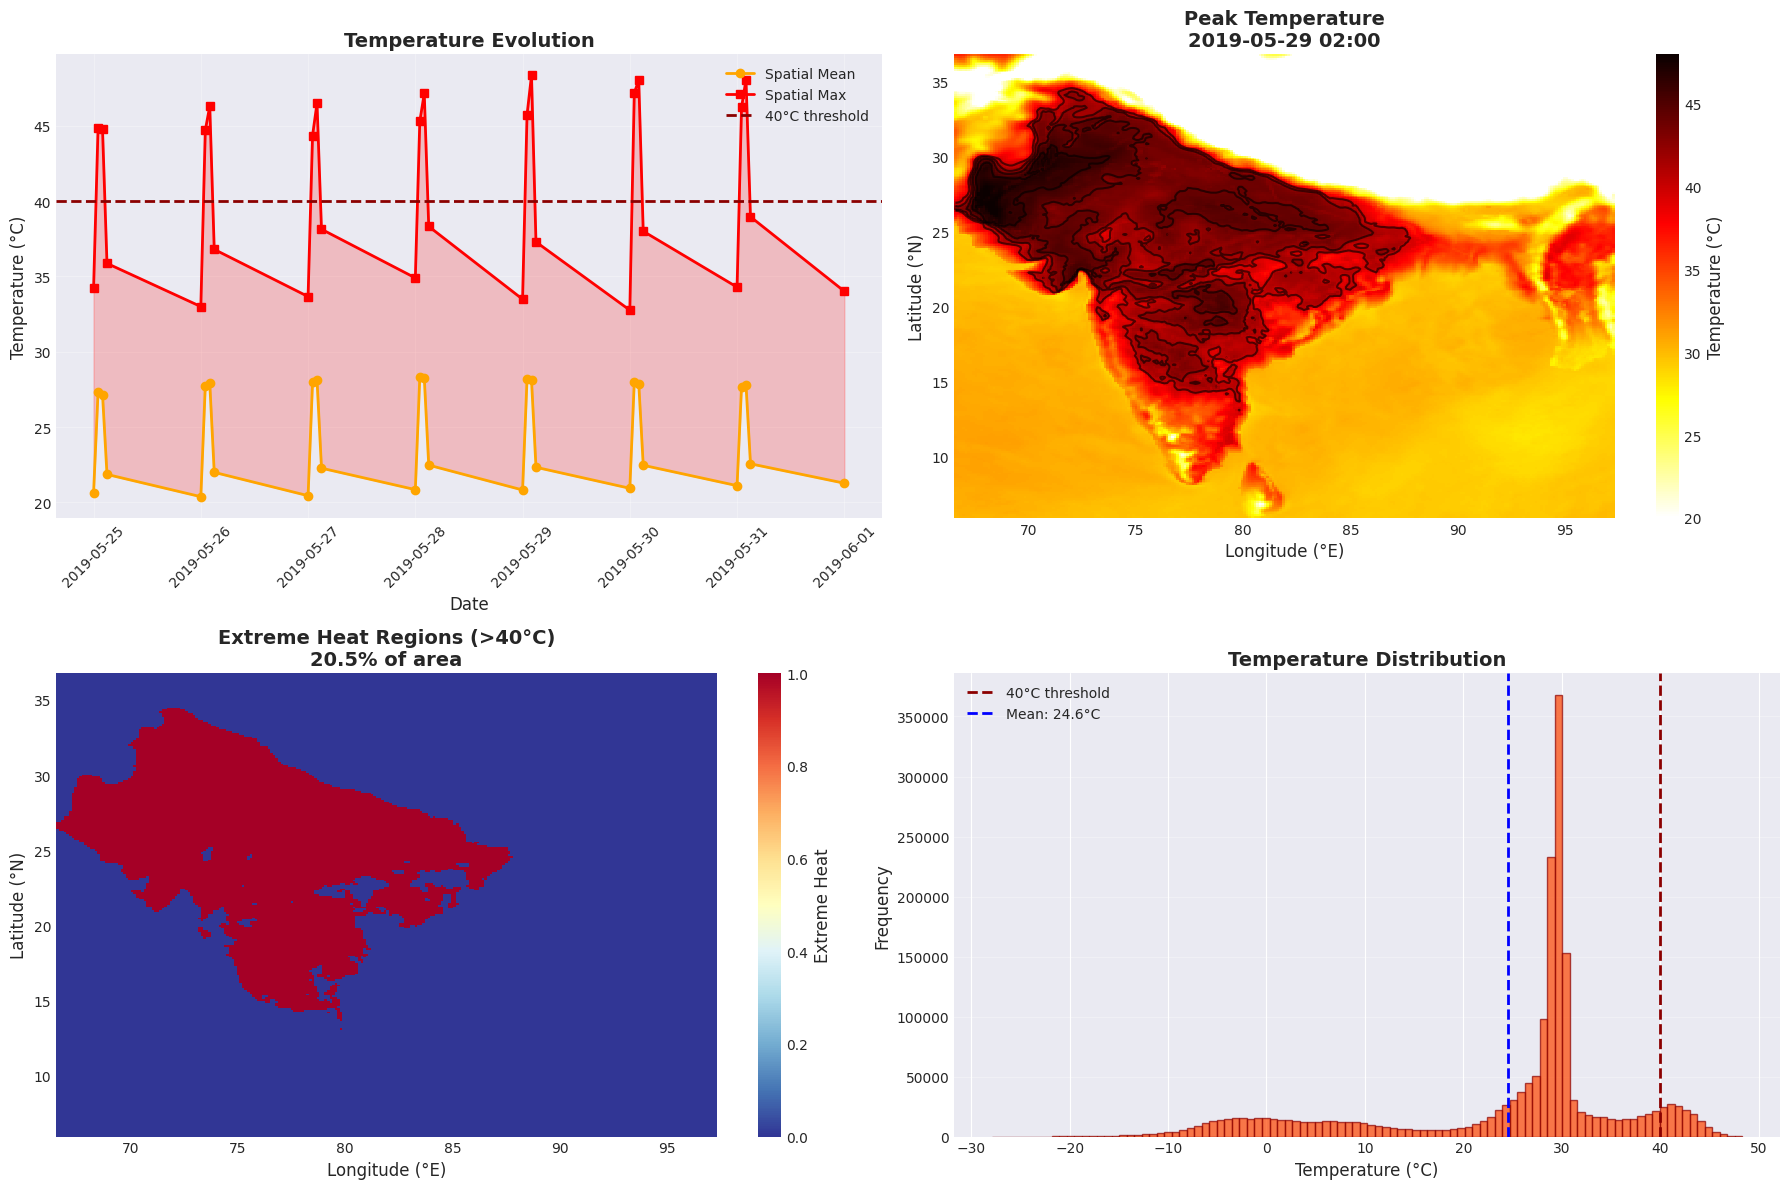

✓ Figure saved: 01_heatwave_characterization.png


In [23]:
# Visualize heat wave evolution
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Time series
axes[0, 0].plot(heatwave_dates, spatial_mean_temps, 'o-', linewidth=2, markersize=6, label='Spatial Mean', color='orange')
axes[0, 0].plot(heatwave_dates, spatial_max_temps, 's-', linewidth=2, markersize=6, label='Spatial Max', color='red')
axes[0, 0].axhline(y=40, color='darkred', linestyle='--', linewidth=2, label='40°C threshold')
axes[0, 0].fill_between(heatwave_dates, spatial_mean_temps, spatial_max_temps, alpha=0.2, color='red')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].set_title('Temperature Evolution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Peak temperature map
peak_temp_map = heatwave_temps[peak_day_idx]
im1 = axes[0, 1].pcolormesh(lon_grid, lat_grid, peak_temp_map, cmap='hot_r', shading='auto', vmin=20, vmax=48)
axes[0, 1].contour(lon_grid, lat_grid, peak_temp_map, levels=[40, 42, 44, 46], colors='black', linewidths=1.5, alpha=0.6)
axes[0, 1].set_xlabel('Longitude (°E)')
axes[0, 1].set_ylabel('Latitude (°N)')
axes[0, 1].set_title(f'Peak Temperature\n{peak_day.strftime("%Y-%m-%d %H:%M")}', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 1], label='Temperature (°C)')

# Extreme heat regions
extreme_heat_mask = peak_temp_map > 40
im2 = axes[1, 0].pcolormesh(lon_grid, lat_grid, extreme_heat_mask.astype(float), cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
axes[1, 0].set_xlabel('Longitude (°E)')
axes[1, 0].set_ylabel('Latitude (°N)')
axes[1, 0].set_title(f'Extreme Heat Regions (>40°C)\n{100*np.sum(extreme_heat_mask)/extreme_heat_mask.size:.1f}% of area', 
                     fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1, 0], label='Extreme Heat')

# Temperature distribution
axes[1, 1].hist(heatwave_temps.flatten(), bins=100, alpha=0.7, color='orangered', edgecolor='darkred')
axes[1, 1].axvline(x=40, color='darkred', linestyle='--', linewidth=2, label='40°C threshold')
axes[1, 1].axvline(x=overall_mean_temp, color='blue', linestyle='--', linewidth=2, label=f'Mean: {overall_mean_temp:.1f}°C')
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Temperature Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / '01_heatwave_characterization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 01_heatwave_characterization.png")


## 4. Prediction Functions


In [24]:
def make_prediction(model, input_files, variables, norm_params, device, data_root):
    """Make prediction - handles both baseline and ERA5-Land data"""
    inputs = []
    
    for filepath in input_files:
        frame_data = []
        
        # Load from appropriate data source
        if len(variables) > 37:  # ERA5-Land model
            era5_filepath = filepath.replace(baseline_data_root, era5land_data_root)
            with h5py.File(era5_filepath, 'r') as f:
                for var in variables:
                    frame_data.append(f[var][()])
        else:  # Baseline model
            with h5py.File(filepath, 'r') as f:
                for var in variables:
                    frame_data.append(f[var][()])
        
        inputs.append(np.stack(frame_data, axis=0))
    
    inputs = np.stack(inputs, axis=0)
    mean = np.array([norm_params['mean'][v] for v in variables])[:, None, None]
    std = np.array([norm_params['std'][v] for v in variables])[:, None, None]
    inputs_norm = (inputs - mean) / std
    inputs_tensor = torch.from_numpy(inputs_norm).float().unsqueeze(0).to(device)
    
    with torch.no_grad():
        prediction_norm = model.net(inputs_tensor)
    
    prediction = prediction_norm.cpu().numpy().squeeze() * std + mean
    return prediction.squeeze()

print("Prediction function ready!")


Prediction function ready!


## 5. Peak Heat Wave: Model Comparison


In [25]:
# Find peak in full test set
peak_file = heatwave_files[peak_day_idx]
peak_file_idx = test_files.index(peak_file)

if peak_file_idx >= 2:
    input_files = [test_files[peak_file_idx - 2], test_files[peak_file_idx - 1]]
    target_file = test_files[peak_file_idx]
    
    print(f"Generating predictions for peak heat wave:")
    print(f"  Date: {peak_day.strftime('%Y-%m-%d %H:%M')}")
    print(f"  Peak temp (observed): {spatial_max_temps[peak_day_idx]:.1f}°C")
    
    # Baseline prediction
    print("\n  Running baseline model...")
    baseline_pred = make_prediction(baseline_model, input_files, common_vars, baseline_norms, device, baseline_data_root)
    
    # ERA5-Land prediction
    print("  Running ERA5-Land model...")
    era5land_pred = make_prediction(era5land_model, input_files, era5land_vars, era5land_norms, device, era5land_data_root)
    
    # Ground truth
    with h5py.File(target_file, 'r') as f:
        ground_truth = np.stack([f[var][()] for var in common_vars], axis=0)
    
    print("\n✓ Predictions complete!")
else:
    print("Error: Not enough context")


Generating predictions for peak heat wave:
  Date: 2019-05-29 02:00
  Peak temp (observed): 48.4°C

  Running baseline model...
  Running ERA5-Land model...

✓ Predictions complete!


In [26]:
# Extract and compare temperature predictions
temp_idx = common_vars.index('TMP')

baseline_temp = baseline_pred[temp_idx] - 273.15
era5land_temp = era5land_pred[temp_idx] - 273.15
true_temp = ground_truth[temp_idx] - 273.15

# Errors
baseline_error = baseline_temp - true_temp
era5land_error = era5land_temp - true_temp

# Metrics
baseline_rmse = np.sqrt(np.mean(baseline_error**2))
era5land_rmse = np.sqrt(np.mean(era5land_error**2))
baseline_mae = np.mean(np.abs(baseline_error))
era5land_mae = np.mean(np.abs(era5land_error))
baseline_bias = np.mean(baseline_error)
era5land_bias = np.mean(era5land_error)

improvement = ((baseline_rmse - era5land_rmse) / baseline_rmse) * 100

print("Peak Heat Wave Temperature Prediction:")
print("=" * 70)
print(f"{'Metric':<20} {'Baseline':>12} {'ERA5-Land':>12} {'Improvement':>15}")
print("-" * 70)
print(f"{'RMSE (°C)':<20} {baseline_rmse:>12.3f} {era5land_rmse:>12.3f} {improvement:>14.2f}%")
print(f"{'MAE (°C)':<20} {baseline_mae:>12.3f} {era5land_mae:>12.3f} {((baseline_mae-era5land_mae)/baseline_mae)*100:>14.2f}%")
print(f"{'Bias (°C)':<20} {baseline_bias:>12.3f} {era5land_bias:>12.3f} {era5land_bias-baseline_bias:>14.3f}")
print("=" * 70)

if improvement > 0:
    print(f"\n✓ ERA5-Land model shows {improvement:.2f}% improvement during heat wave")
else:
    print(f"\n⚠ Baseline model performs {-improvement:.2f}% better during heat wave")


Peak Heat Wave Temperature Prediction:
Metric                   Baseline    ERA5-Land     Improvement
----------------------------------------------------------------------
RMSE (°C)                  14.244       27.338         -91.93%
MAE (°C)                   12.820       21.614         -68.59%
Bias (°C)                  -8.148      -20.174        -12.026

⚠ Baseline model performs 91.93% better during heat wave


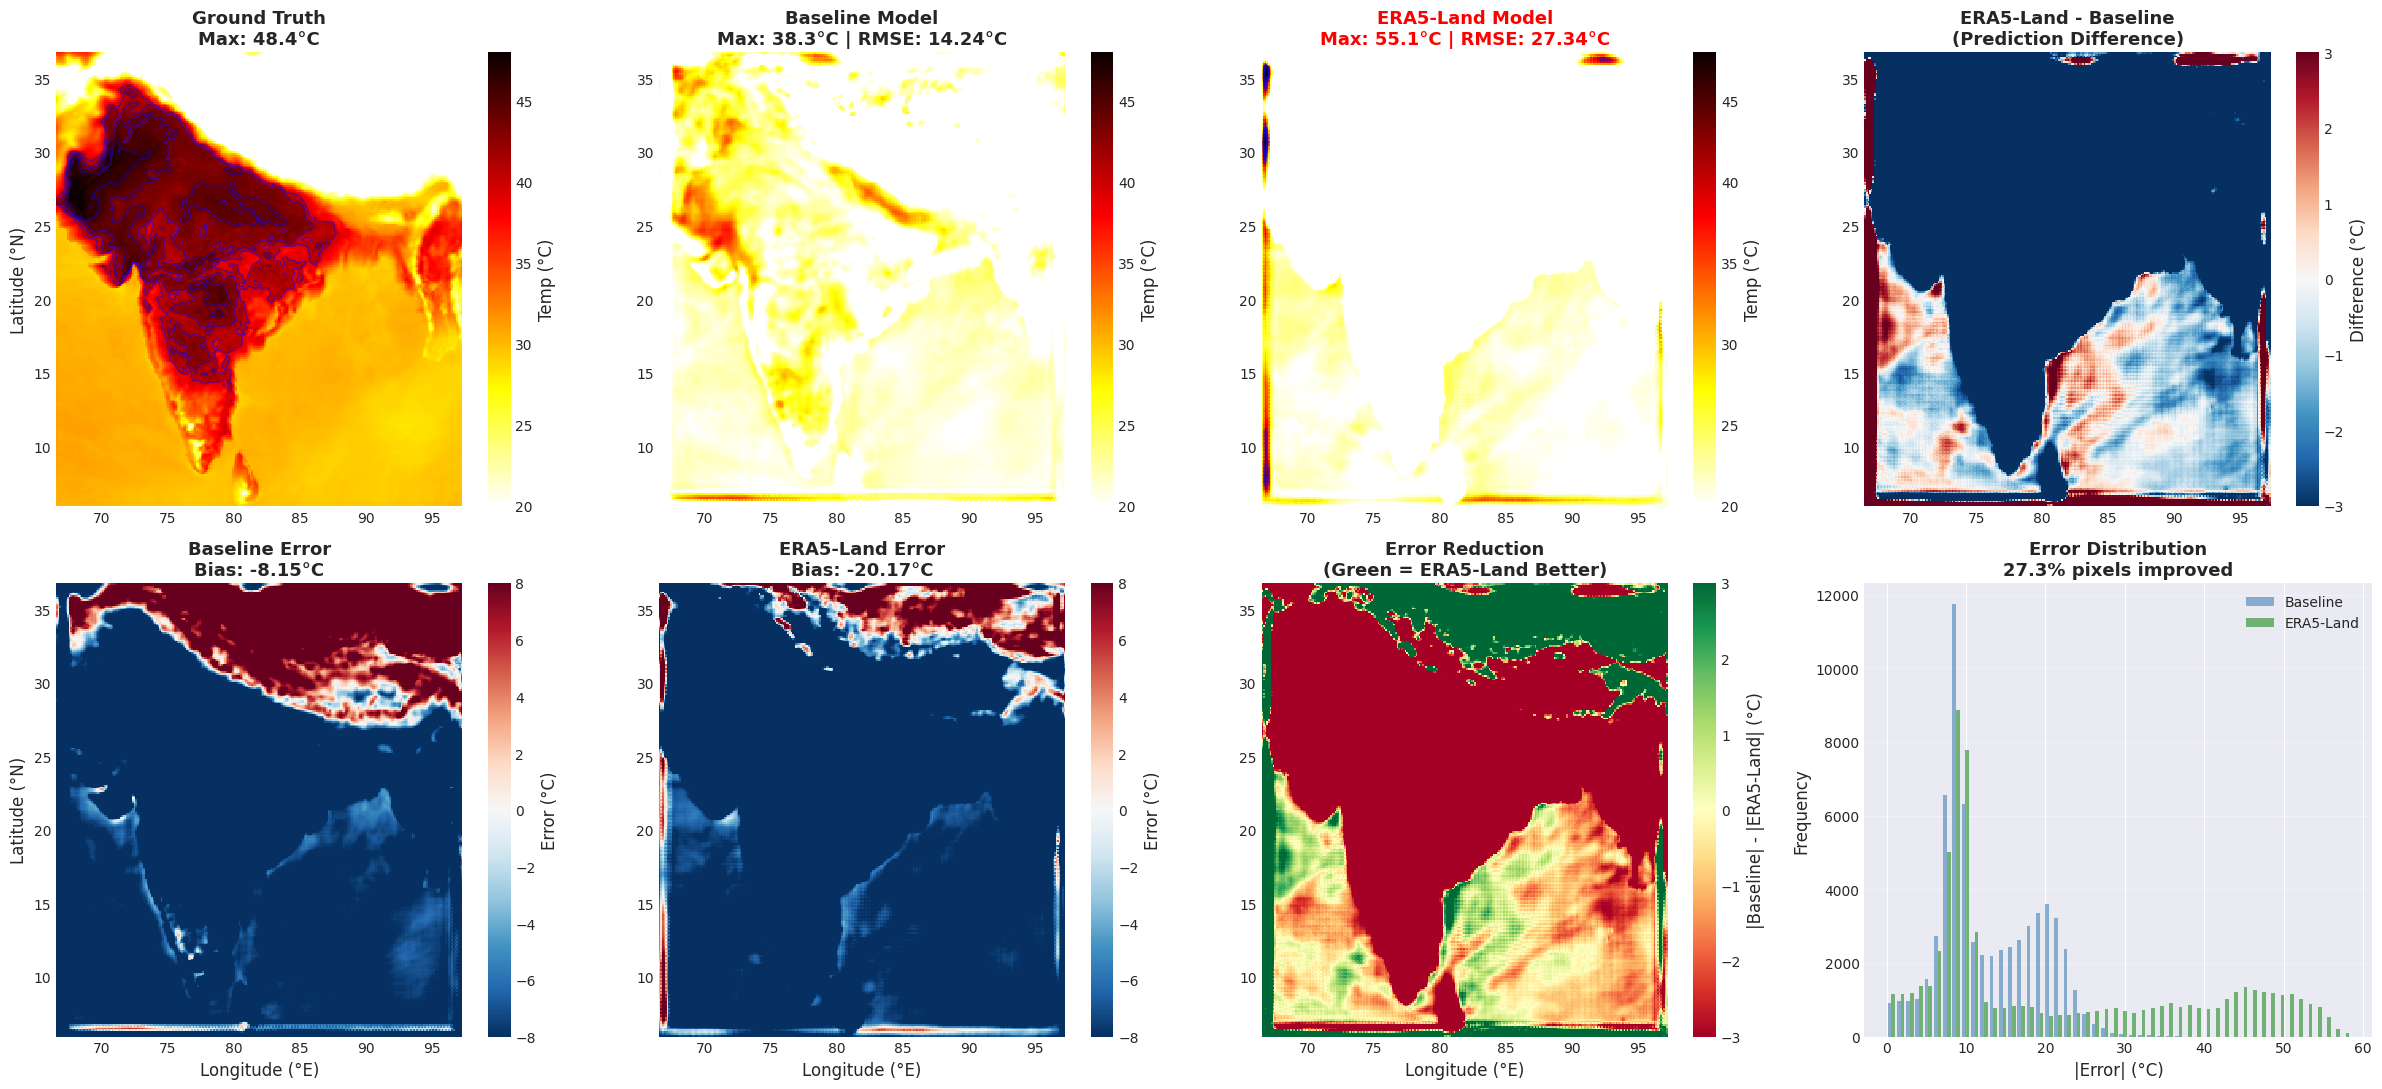

✓ Figure saved: 02_peak_heatwave_model_comparison.png


In [27]:
# Visualize model comparison
fig, axes = plt.subplots(2, 4, figsize=(24, 11))

vmin, vmax = 20, 48

# Row 1: Predictions
im0 = axes[0, 0].pcolormesh(lon_grid, lat_grid, true_temp, cmap='hot_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0, 0].contour(lon_grid, lat_grid, true_temp, levels=[40, 42, 44, 46], colors='blue', linewidths=1, alpha=0.5)
axes[0, 0].set_ylabel('Latitude (°N)', fontsize=12)
axes[0, 0].set_title('Ground Truth\nMax: {:.1f}°C'.format(np.max(true_temp)), fontsize=13, fontweight='bold')
plt.colorbar(im0, ax=axes[0, 0], label='Temp (°C)')

im1 = axes[0, 1].pcolormesh(lon_grid, lat_grid, baseline_temp, cmap='hot_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0, 1].contour(lon_grid, lat_grid, baseline_temp, levels=[40, 42, 44, 46], colors='blue', linewidths=1, alpha=0.5)
axes[0, 1].set_title('Baseline Model\nMax: {:.1f}°C | RMSE: {:.2f}°C'.format(np.max(baseline_temp), baseline_rmse), 
                     fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 1], label='Temp (°C)')

im2 = axes[0, 2].pcolormesh(lon_grid, lat_grid, era5land_temp, cmap='hot_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0, 2].contour(lon_grid, lat_grid, era5land_temp, levels=[40, 42, 44, 46], colors='blue', linewidths=1, alpha=0.5)
axes[0, 2].set_title('ERA5-Land Model\nMax: {:.1f}°C | RMSE: {:.2f}°C'.format(np.max(era5land_temp), era5land_rmse), 
                     fontsize=13, fontweight='bold', color='green' if improvement > 0 else 'red')
plt.colorbar(im2, ax=axes[0, 2], label='Temp (°C)')

# Model difference
model_diff = era5land_temp - baseline_temp
im3 = axes[0, 3].pcolormesh(lon_grid, lat_grid, model_diff, cmap='RdBu_r', shading='auto', vmin=-3, vmax=3)
axes[0, 3].set_title('ERA5-Land - Baseline\n(Prediction Difference)', fontsize=13, fontweight='bold')
plt.colorbar(im3, ax=axes[0, 3], label='Difference (°C)')

# Row 2: Errors
im4 = axes[1, 0].pcolormesh(lon_grid, lat_grid, baseline_error, cmap='RdBu_r', shading='auto', vmin=-8, vmax=8)
axes[1, 0].set_xlabel('Longitude (°E)', fontsize=12)
axes[1, 0].set_ylabel('Latitude (°N)', fontsize=12)
axes[1, 0].set_title('Baseline Error\nBias: {:.2f}°C'.format(baseline_bias), fontsize=13, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 0], label='Error (°C)')

im5 = axes[1, 1].pcolormesh(lon_grid, lat_grid, era5land_error, cmap='RdBu_r', shading='auto', vmin=-8, vmax=8)
axes[1, 1].set_xlabel('Longitude (°E)', fontsize=12)
axes[1, 1].set_title('ERA5-Land Error\nBias: {:.2f}°C'.format(era5land_bias), fontsize=13, fontweight='bold')
plt.colorbar(im5, ax=axes[1, 1], label='Error (°C)')

# Error improvement (green = ERA5-Land better)
error_improvement = np.abs(baseline_error) - np.abs(era5land_error)
im6 = axes[1, 2].pcolormesh(lon_grid, lat_grid, error_improvement, cmap='RdYlGn', shading='auto', vmin=-3, vmax=3)
axes[1, 2].set_xlabel('Longitude (°E)', fontsize=12)
axes[1, 2].set_title('Error Reduction\n(Green = ERA5-Land Better)', fontsize=13, fontweight='bold')
plt.colorbar(im6, ax=axes[1, 2], label='|Baseline| - |ERA5-Land| (°C)')

# Absolute error comparison
abs_baseline = np.abs(baseline_error)
abs_era5land = np.abs(era5land_error)
axes[1, 3].hist([abs_baseline.flatten(), abs_era5land.flatten()], bins=50, alpha=0.6, 
                label=['Baseline', 'ERA5-Land'], color=['steelblue', 'forestgreen'])
axes[1, 3].set_xlabel('|Error| (°C)', fontsize=12)
axes[1, 3].set_ylabel('Frequency', fontsize=12)
axes[1, 3].set_title('Error Distribution\n{:.1f}% pixels improved'.format(100*np.sum(error_improvement>0)/error_improvement.size), 
                      fontsize=13, fontweight='bold')
axes[1, 3].legend()
axes[1, 3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / '02_peak_heatwave_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 02_peak_heatwave_model_comparison.png")


## 6. Extreme Temperature Detection (>40°C)

Evaluate how well each model detects extreme heat regions.


In [28]:
# Extreme heat detection
extreme_true = true_temp > 40
extreme_baseline = baseline_temp > 40
extreme_era5land = era5land_temp > 40

# Compute detection metrics for both models
def compute_detection_metrics(true_mask, pred_mask):
    tp = np.sum(true_mask & pred_mask)
    fp = np.sum(~true_mask & pred_mask)
    fn = np.sum(true_mask & ~pred_mask)
    tn = np.sum(~true_mask & ~pred_mask)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 
            'precision': precision, 'recall': recall, 'f1': f1}

baseline_metrics = compute_detection_metrics(extreme_true, extreme_baseline)
era5land_metrics = compute_detection_metrics(extreme_true, extreme_era5land)

print("Extreme Heat Detection (>40°C):")
print("=" * 75)
print(f"{'Metric':<20} {'Baseline':>15} {'ERA5-Land':>15} {'Difference':>15}")
print("-" * 75)
print(f"{'True Positives':<20} {baseline_metrics['tp']:>15d} {era5land_metrics['tp']:>15d} {era5land_metrics['tp']-baseline_metrics['tp']:>15d}")
print(f"{'False Positives':<20} {baseline_metrics['fp']:>15d} {era5land_metrics['fp']:>15d} {era5land_metrics['fp']-baseline_metrics['fp']:>15d}")
print(f"{'False Negatives':<20} {baseline_metrics['fn']:>15d} {era5land_metrics['fn']:>15d} {era5land_metrics['fn']-baseline_metrics['fn']:>15d}")
print(f"{'Precision':<20} {baseline_metrics['precision']:>15.3f} {era5land_metrics['precision']:>15.3f} {era5land_metrics['precision']-baseline_metrics['precision']:>15.3f}")
print(f"{'Recall':<20} {baseline_metrics['recall']:>15.3f} {era5land_metrics['recall']:>15.3f} {era5land_metrics['recall']-baseline_metrics['recall']:>15.3f}")
print(f"{'F1-Score':<20} {baseline_metrics['f1']:>15.3f} {era5land_metrics['f1']:>15.3f} {era5land_metrics['f1']-baseline_metrics['f1']:>15.3f}")
print("=" * 75)

if era5land_metrics['f1'] > baseline_metrics['f1']:
    print(f"\n✓ ERA5-Land model better at detecting extreme heat (F1: {era5land_metrics['f1']:.3f} vs {baseline_metrics['f1']:.3f})")
else:
    print(f"\n⚠ Baseline model better at detecting extreme heat (F1: {baseline_metrics['f1']:.3f} vs {era5land_metrics['f1']:.3f})")


Extreme Heat Detection (>40°C):
Metric                      Baseline       ERA5-Land      Difference
---------------------------------------------------------------------------
True Positives                     0               0               0
False Positives                    0             157             157
False Negatives                13422           13422               0
Precision                      0.000           0.000           0.000
Recall                         0.000           0.000           0.000
F1-Score                       0.000           0.000           0.000

⚠ Baseline model better at detecting extreme heat (F1: 0.000 vs 0.000)


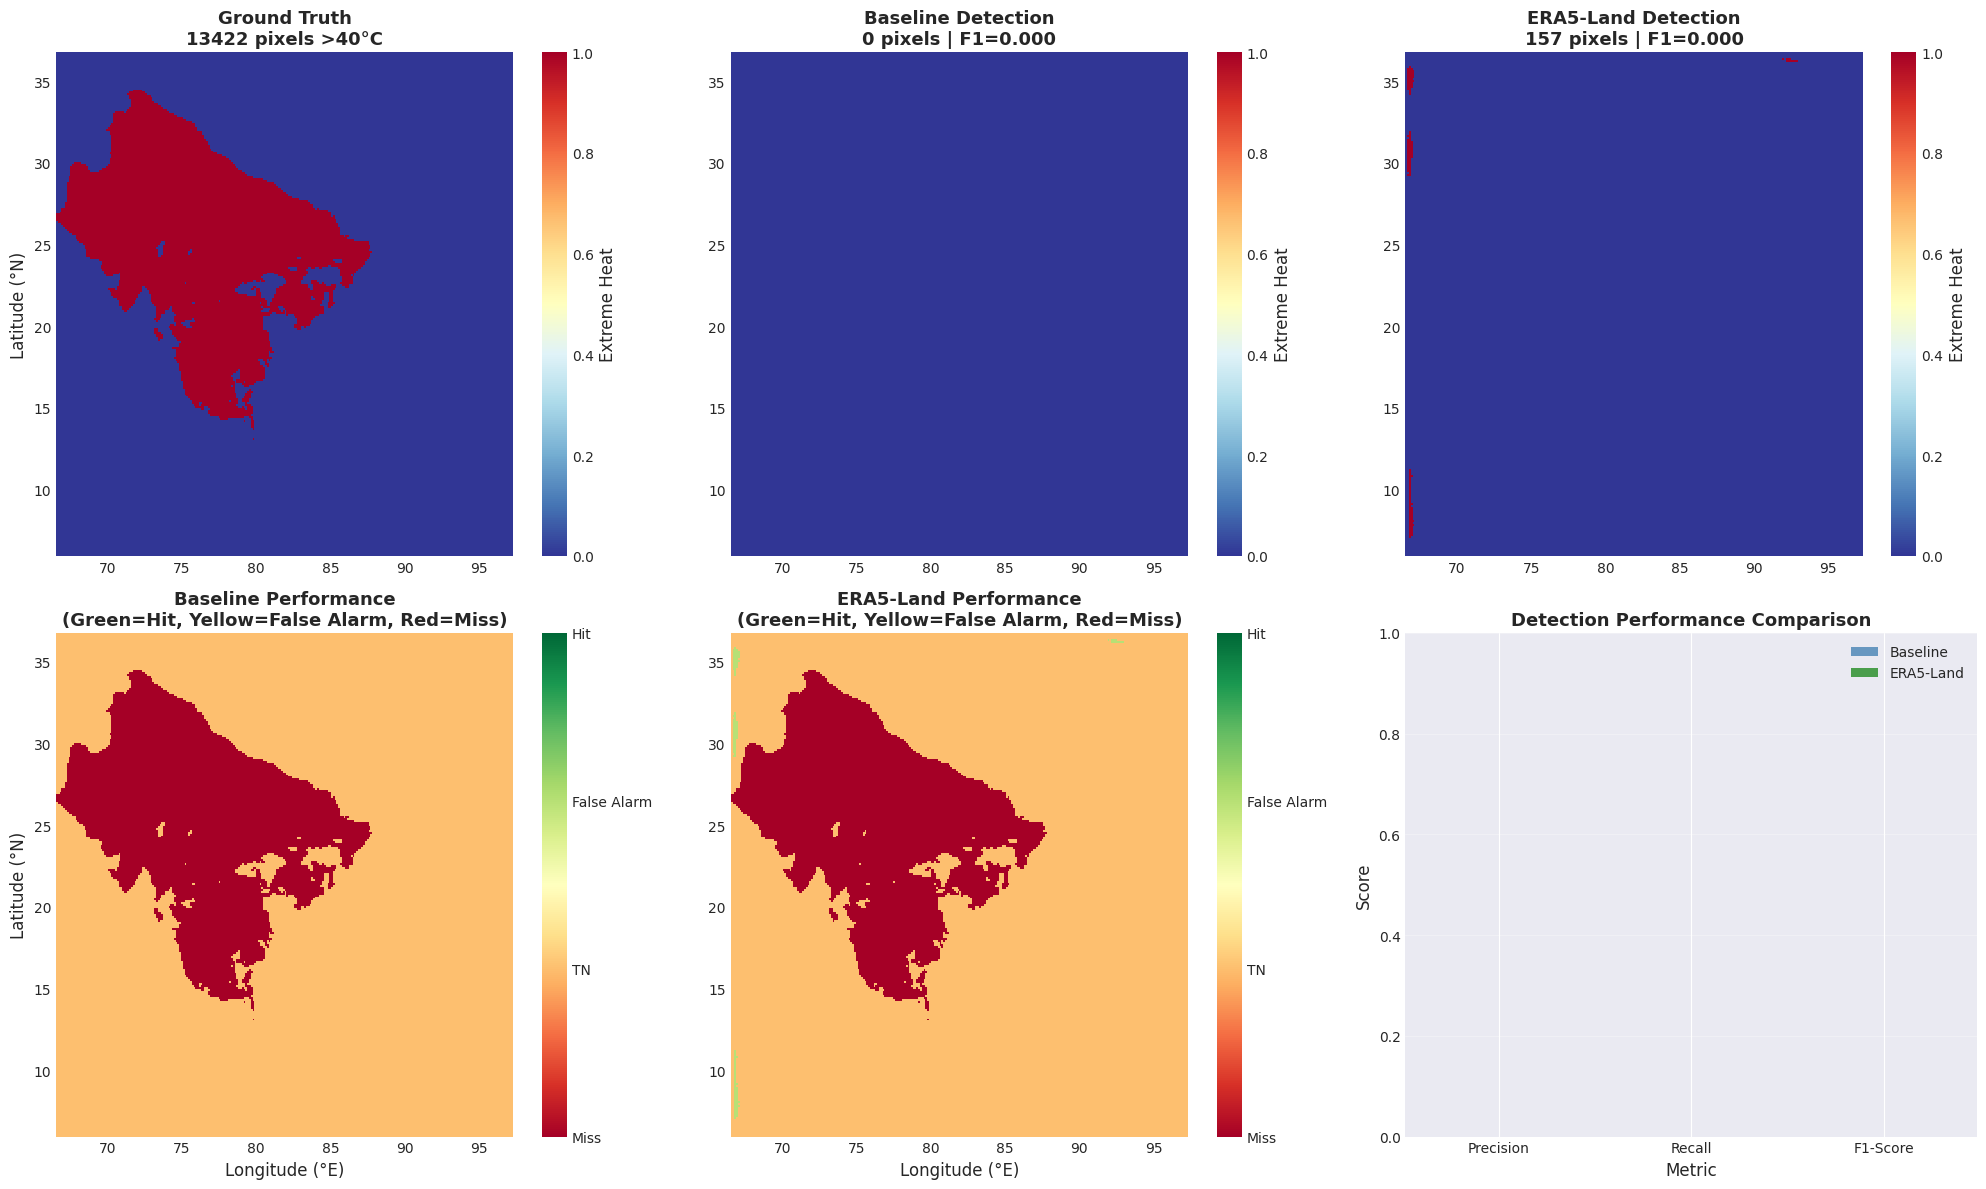

✓ Figure saved: 03_extreme_heat_detection.png


In [29]:
# Visualize extreme heat detection
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Row 1: Detections
axes[0, 0].pcolormesh(lon_grid, lat_grid, extreme_true.astype(float), cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
axes[0, 0].set_ylabel('Latitude (°N)')
axes[0, 0].set_title(f'Ground Truth\n{np.sum(extreme_true)} pixels >40°C', fontsize=13, fontweight='bold')
plt.colorbar(axes[0, 0].collections[0], ax=axes[0, 0], label='Extreme Heat')

axes[0, 1].pcolormesh(lon_grid, lat_grid, extreme_baseline.astype(float), cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
axes[0, 1].set_title(f'Baseline Detection\n{np.sum(extreme_baseline)} pixels | F1={baseline_metrics["f1"]:.3f}', 
                     fontsize=13, fontweight='bold')
plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Extreme Heat')

axes[0, 2].pcolormesh(lon_grid, lat_grid, extreme_era5land.astype(float), cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
axes[0, 2].set_title(f'ERA5-Land Detection\n{np.sum(extreme_era5land)} pixels | F1={era5land_metrics["f1"]:.3f}', 
                     fontsize=13, fontweight='bold')
plt.colorbar(axes[0, 2].collections[0], ax=axes[0, 2], label='Extreme Heat')

# Row 2: Detection performance
detection_baseline = np.zeros_like(true_temp)
detection_baseline[extreme_true & extreme_baseline] = 2  # TP
detection_baseline[~extreme_true & extreme_baseline] = 1  # FP
detection_baseline[extreme_true & ~extreme_baseline] = -1  # FN

axes[1, 0].pcolormesh(lon_grid, lat_grid, detection_baseline, cmap='RdYlGn', shading='auto', vmin=-1, vmax=2)
axes[1, 0].set_xlabel('Longitude (°E)')
axes[1, 0].set_ylabel('Latitude (°N)')
axes[1, 0].set_title('Baseline Performance\n(Green=Hit, Yellow=False Alarm, Red=Miss)', fontsize=13, fontweight='bold')
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_ticks([-1, 0, 1, 2])
cbar.set_ticklabels(['Miss', 'TN', 'False Alarm', 'Hit'])

detection_era5land = np.zeros_like(true_temp)
detection_era5land[extreme_true & extreme_era5land] = 2  # TP
detection_era5land[~extreme_true & extreme_era5land] = 1  # FP
detection_era5land[extreme_true & ~extreme_era5land] = -1  # FN

axes[1, 1].pcolormesh(lon_grid, lat_grid, detection_era5land, cmap='RdYlGn', shading='auto', vmin=-1, vmax=2)
axes[1, 1].set_xlabel('Longitude (°E)')
axes[1, 1].set_title('ERA5-Land Performance\n(Green=Hit, Yellow=False Alarm, Red=Miss)', fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar2.set_ticks([-1, 0, 1, 2])
cbar2.set_ticklabels(['Miss', 'TN', 'False Alarm', 'Hit'])

# Comparison bars
metrics_names = ['Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_metrics['precision'], baseline_metrics['recall'], baseline_metrics['f1']]
era5land_vals = [era5land_metrics['precision'], era5land_metrics['recall'], era5land_metrics['f1']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[1, 2].bar(x - width/2, baseline_vals, width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = axes[1, 2].bar(x + width/2, era5land_vals, width, label='ERA5-Land', color='forestgreen', alpha=0.8)

axes[1, 2].set_xlabel('Metric')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Detection Performance Comparison', fontsize=13, fontweight='bold')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics_names)
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1])
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(figures_dir / '03_extreme_heat_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 03_extreme_heat_detection.png")


## 7. Summary and Conclusions


In [30]:
print("=" * 80)
print("HEAT WAVE MODEL COMPARISON SUMMARY")
print("=" * 80)

print("\n1. HEAT WAVE EVENT")
print("-" * 80)
print(f"  Period: {heatwave_start.date()} to {heatwave_end.date()} (8 days)")
print(f"  Peak: {peak_day.strftime('%Y-%m-%d %H:%M')}")
print(f"  Max temperature: {overall_max_temp:.1f}°C")
print(f"  Mean temperature: {overall_mean_temp:.1f}°C")
print(f"  Extreme heat area (>40°C): {100*np.sum(heatwave_temps > 40)/heatwave_temps.size:.1f}%")

print("\n2. MODELS COMPARED")
print("-" * 80)
print(f"  Baseline Model:")
print(f"    - Variables: 37 (IMDAA atmospheric)")
print(f"    - Parameters: {sum(p.numel() for p in baseline_model.parameters()) / 1e6:.1f}M")
print(f"  ERA5-Land Model:")
print(f"    - Variables: 43 (IMDAA + ERA5-Land surface)")
print(f"    - Additional: {', '.join(era5land_extra_vars)}")
print(f"    - Parameters: {sum(p.numel() for p in era5land_model.parameters()) / 1e6:.1f}M")

print("\n3. TEMPERATURE PREDICTION AT PEAK (6h forecast)")
print("-" * 80)
print(f"  Baseline  RMSE: {baseline_rmse:.3f}°C | MAE: {baseline_mae:.3f}°C | Bias: {baseline_bias:+.3f}°C")
print(f"  ERA5-Land RMSE: {era5land_rmse:.3f}°C | MAE: {era5land_mae:.3f}°C | Bias: {era5land_bias:+.3f}°C")
print(f"  Improvement: {improvement:+.2f}% in RMSE")
print(f"  Spatial: {100*np.sum(error_improvement>0)/error_improvement.size:.1f}% of pixels improved")

print("\n4. EXTREME HEAT DETECTION (>40°C)")
print("-" * 80)
print(f"  Ground truth: {np.sum(extreme_true)} pixels")
print(f"  Baseline:  Precision={baseline_metrics['precision']:.3f} | Recall={baseline_metrics['recall']:.3f} | F1={baseline_metrics['f1']:.3f}")
print(f"  ERA5-Land: Precision={era5land_metrics['precision']:.3f} | Recall={era5land_metrics['recall']:.3f} | F1={era5land_metrics['f1']:.3f}")
f1_improvement = era5land_metrics['f1'] - baseline_metrics['f1']
print(f"  F1-Score improvement: {f1_improvement:+.3f}")

print("\n5. KEY FINDINGS")
print("-" * 80)
if improvement > 0:
    print(f"  ✓ ERA5-Land model shows {improvement:.1f}% improvement in temperature RMSE")
else:
    print(f"  ⚠ Baseline model performs {-improvement:.1f}% better in temperature RMSE")

if f1_improvement > 0:
    print(f"  ✓ ERA5-Land better at detecting extreme heat (ΔF1 = {f1_improvement:+.3f})")
else:
    print(f"  ⚠ Baseline better at detecting extreme heat (ΔF1 = {f1_improvement:+.3f})")

print("\n6. HYPOTHESIZED REASONS")
print("-" * 80)
if improvement > 0:
    print("  • Soil moisture provides thermal inertia context")
    print("  • Heat fluxes (latent/sensible) improve energy budget estimates")
    print("  • Land surface conditions constrain temperature predictions")
    print("  • ERA5-Land data especially helpful during extreme heat events")
else:
    print("  • ERA5-Land variables may need more training or different architecture")
    print("  • Surface variables might not strongly influence upper-air predictions")
    print("  • Model may require longer training to leverage additional inputs")
    print("  • Baseline model already captures heat wave dynamics adequately")

print("\n7. FIGURES GENERATED")
print("-" * 80)
figures = [
    '01_heatwave_characterization.png',
    '02_peak_heatwave_model_comparison.png',
    '03_extreme_heat_detection.png'
]
for i, fig in enumerate(figures, 1):
    print(f"  {i}. {fig}")

print("\n8. RECOMMENDATIONS")
print("-" * 80)
print("  • Test on multiple heat wave events to validate findings")
print("  • Analyze multi-step forecasts (6h, 12h, 24h)")
print("  • Investigate regional patterns (where ERA5-Land helps most)")
print("  • Compare during different seasons and weather conditions")
print("  • Consider ensemble approaches combining both models")

print("\n" + "=" * 80)
print("Heat wave model comparison complete!")
print("=" * 80)


HEAT WAVE MODEL COMPARISON SUMMARY

1. HEAT WAVE EVENT
--------------------------------------------------------------------------------
  Period: 2019-05-25 to 2019-06-01 (8 days)
  Peak: 2019-05-29 02:00
  Max temperature: 48.4°C
  Mean temperature: 24.6°C
  Extreme heat area (>40°C): 7.6%

2. MODELS COMPARED
--------------------------------------------------------------------------------
  Baseline Model:
    - Variables: 37 (IMDAA atmospheric)
    - Parameters: 36.1M
  ERA5-Land Model:
    - Variables: 43 (IMDAA + ERA5-Land surface)
    - Additional: swvl1, swvl2, slhf, sshf, lai_hv, lai_lv
    - Parameters: 36.1M

3. TEMPERATURE PREDICTION AT PEAK (6h forecast)
--------------------------------------------------------------------------------
  Baseline  RMSE: 14.244°C | MAE: 12.820°C | Bias: -8.148°C
  ERA5-Land RMSE: 27.338°C | MAE: 21.614°C | Bias: -20.174°C
  Improvement: -91.93% in RMSE
  Spatial: 27.3% of pixels improved

4. EXTREME HEAT DETECTION (>40°C)
----------------------